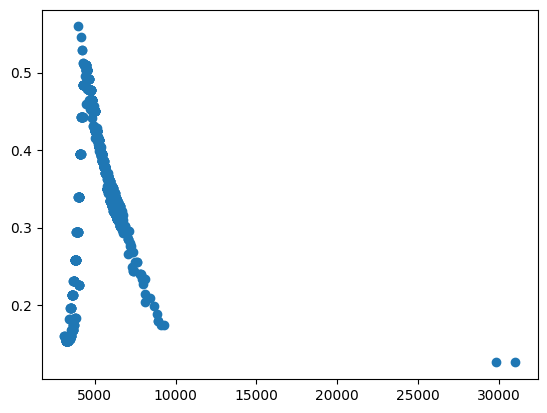

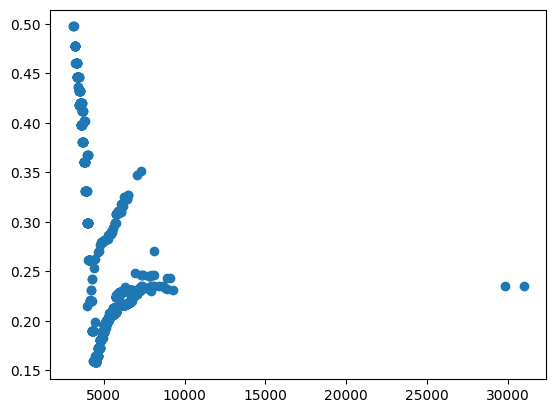

In [25]:
from transitleastsquares import transitleastsquares, catalog_info, cleaned_array
import pandas as pd
import matplotlib.pyplot as plt
#pull tic_id_temp from stellar_params_CTL.csv

df = pd.read_csv('stellar_params_CTL.csv')
tic_ids = df['id'].tolist()
tic_temps = df['teff'].tolist()
tic_id_temp = list(zip(tic_ids, tic_temps))  # Creates pairs of (id, temp)


temp_ld_df = pd.DataFrame(columns=['teff', 'a', 'b'])
for tic_id, temp in tic_id_temp:
    ab, mass, mass_min, mass_max, radius, radius_min, radius_max = catalog_info(TIC_ID=tic_id)
    # print(f"TIC {tic_id} with Teff={temp}K")
    # print('Stellar mass', mass)
    # print('Stellar radius', radius)
    # print('Quadratic LD parameters (a,b)=', ab)
    temp_ld_df.loc[len(temp_ld_df)] = {'teff': temp, 'a': ab[0], 'b': ab[1]}

plt.scatter(temp_ld_df['teff'], temp_ld_df['a'], marker='o', label='a')
plt.show()
plt.scatter(temp_ld_df['teff'], temp_ld_df['b'], marker='o', label='b')

In [26]:
import numpy as np
import pandas as pd

# Create temperature bins of 500K with proper centers
temp_bins = np.arange(3000, 7750, 500)  # 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000, 7500
bin_centers = temp_bins[:-1] + 250  # 3250, 3750, 4250, 4750, 5250, 5750, 6250, 6750
temp_ld_df['temp_bin'] = pd.cut(temp_ld_df['teff'], bins=temp_bins, labels=bin_centers)

# Calculate average LD coefficients and counts per bin
bin_stats = temp_ld_df.groupby('temp_bin').agg({
    'a': ['mean', 'std'],
    'b': ['mean', 'std'],
    'teff': 'count'
}).round(4)
print(bin_stats['a_mean'], bin_stats['b_mean'])

# Flatten column names
bin_stats.columns = ['a_mean', 'a_std', 'b_mean', 'b_std', 'star_count']
bin_stats = bin_stats.reset_index()

# Remove bins with no data
bin_stats = bin_stats.dropna()

print("Limb Darkening Statistics by Temperature Bin:")
print(bin_stats)

# Plot average LD coefficients with error bars
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Plot 'a' coefficient
ax1.scatter(temp_ld_df['teff'], temp_ld_df['a'], color = 'grey', label='a', alpha=0.1)
ax1.errorbar(bin_stats['temp_bin'], bin_stats['a_mean'], 
         yerr=bin_stats['a_std'], marker='o', markersize=8, label='a coefficient')
ax1.set_xlabel('Temperature (K)')
ax1.set_ylabel('Average LD coefficient "a"')
ax1.set_title('Average Limb Darkening Coefficient "a" vs Temperature')
ax1.set_xlim(3000, 7500)

ax1.grid(True, alpha=0.3)
ax1.legend()

# Add star counts as text annotations
for i, row in bin_stats.iterrows():
    ax1.annotate(f'n={int(row["star_count"])}', 
                (row['temp_bin'], row['a_mean']), 
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

# Plot 'b' coefficient
ax2.scatter(temp_ld_df['teff'], temp_ld_df['b'],  label='b', color='grey', alpha=0.1)
ax2.errorbar(bin_stats['temp_bin'], bin_stats['b_mean'], 
         yerr=bin_stats['b_std'], marker='s', markersize=8, label='b coefficient', color='red')
ax2.set_xlabel('Temperature (K)')
ax2.set_ylabel('Average LD coefficient "b"')
ax2.set_title('Average Limb Darkening Coefficient "b" vs Temperature')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(3000, 7500)
ax2.legend()

# Add star counts as text annotations
for i, row in bin_stats.iterrows():
    ax2.annotate(f'n={int(row["star_count"])}', 
                (row['temp_bin'], row['b_mean']), 
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

# plt.tight_layout()
# plt.show()


# Add star counts
# for i, row in bin_stats.iterrows():
#     plt.text(row['temp_bin'], max(row['a_mean'], row['b_mean']) + 0.05, 
#              f'n={int(row["star_count"])}', ha='center', fontsize=9)



KeyError: 'a_mean'

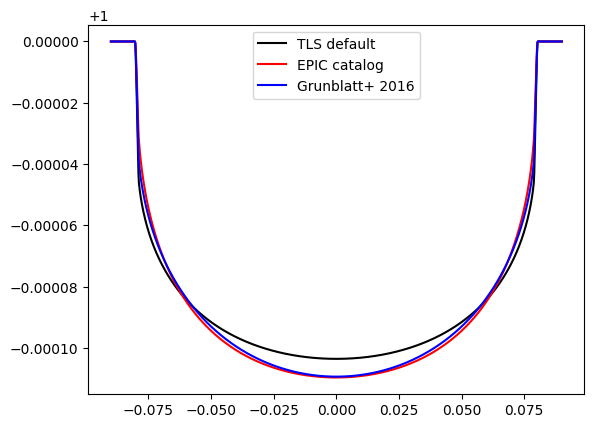

In [3]:
import numpy
import batman
import matplotlib.pyplot as plt

def transit(ld):  # Use batman to create transits
    ma = batman.TransitParams()
    ma.t0 = 0  # time of inferior conjunction; first transit is X days after start
    ma.per = 10  # orbital period
    ma.rp = 6371 / 696342  # 6371 planet radius (in units of stellar radii)
    ma.a = 20  # semi-major axis (in units of stellar radii)
    ma.inc = 90  # orbital inclination (in degrees)
    ma.ecc = 0  # eccentricity
    ma.w = 90  # longitude of periastron (in degrees)
    ma.u = ld  # limb darkening coefficients
    ma.limb_dark = "quadratic"  # limb darkening model
    m = batman.TransitModel(ma, time)  # initializes model
    return m.light_curve(ma)

# Plot raw data
time = numpy.linspace(-0.09, 0.09, 1000)
plt.figure()
plt.plot(time, transit(ld=[0.4804, 0.1867]), color='black', label='TLS default')
plt.plot(time, transit(ld=ab), color='red', label='EPIC catalog')
plt.plot(time, transit(ld=[0.6505, 0.1041]), color='blue', label='Grunblatt+ 2016')
plt.legend();